# Galaxy SNR estimation: plotting only

This notebook contains the plotting/inspection cells moved out of the main calculation notebook. It assumes the checkpoint files already exist under `/Users/tliu/oh_suppression/result`.


In [1]:
import astropy.units as u

from astropy.modeling.models import Sersic2D
# Source: https://docs.astropy.org/en/stable/api/astropy.modeling.functional_models.Sersic2D.html

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import special #import jv, kv
# from scipy.special import j1 # Bessel function of the first kind of order 1, for the diffraction pattern calculation
from scipy.optimize import root_scalar
from scipy.constants import c, epsilon_0, mu_0, pi
import scipy.integrate as integrate

In [3]:
from dataclasses import dataclass
import pandas as pd

In [4]:
from joblib import Parallel, delayed
import os

In [5]:
import sys
from pathlib import Path

src_path = Path("/Users/tliu/oh_suppression/codes/src")

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from oh_suppression.coupling import *

In [6]:
from oh_suppression.point_source_coupling import *
from oh_suppression.flat_background_coupling import *
from oh_suppression.extended_source_coupling import *

In [23]:
# wavelength of beam in vacuum
lam0 = 1.5e-6 

# 
core_radius_range_test = np.arange(2.5e-6, 5.74e-6 + 0.01e-6, 0.01e-6) # range of core radius to test, from 2.5 microns to 5.7415 microns, in steps of 0.01 microns. Note arange is exclusive of the upper limit, so we add 0.01e-6 to include 5.74e-6 in the range. 

In [24]:
NA = 0.1
F_fibre = 1 / (2 * np.tan(np.arcsin(NA)))
Magnification = F_fibre / 49.9
F_focus = 49.9

D_M1 = 8.0 # Diameter of the primary mirror in meters
D_obstruction = 1.0 # Diameter of the central obstruction in meters
alpha_vlt = D_obstruction / D_M1 # Ratio of the central obstruction to the primary mirror diameter (0.125 for VLT)
rad_to_arcsec = (180 / np.pi) * 3600
plate_scale_coude = rad_to_arcsec / (F_focus * D_M1)  # arcsec / metre at telescope focal plane
plate_scale_demag = plate_scale_coude / Magnification # arcsec / metre at the demagnified fibre input plane

In [25]:
print(f"Plate scale at the Coudé focus: {plate_scale_coude*1e-3:.2f} arcsec/mm")

Plate scale at the Coudé focus: 0.52 arcsec/mm


In [26]:
n_sersic = 3.335 # sersic index, n>0.36
Re_arcsec = 0.101 # half light radius in arcseconds
q_param = 0.514 # projected axis ratio of the galaxy, b/a, where b is the semi-minor axis and a is the semi-major axis. This is used to calculate the effective radius in the direction of the fibre input plane.
# PA = 0 # assumed to be 0 for simplicity, but can be adjusted based on the orientation of the galaxy in the sky.
PA_deg = -88.7
ellip = 1 - q_param # ellipticity of the galaxy, defined as 1 - (b/a)

In [27]:
# Sersic profile has a scaling constant b_n, for n>0.36, b_n can be approximated as b_n = 2n - 1/3 + 4/(405n) + 46/(25515n^2) + 131/(1148175n^3) 
# - 2194697/(30690717750n^4)
b_n = 2 * n_sersic - 1/3 + 4/(405*n_sersic) + 46/(25515*n_sersic**2) + 131/(1148175*n_sersic**3) - 2194697/(30690717750*n_sersic**4)

In [28]:
# Fibre front grid in metres

r_max = 125e-6 # maximum radius of the CLADDING region to be considered in the 2D grid, in meters
n_grid = 1000 

x_1d = np.linspace(-r_max, r_max, n_grid)
y_1d = np.linspace(-r_max, r_max, n_grid)

x, y = np.meshgrid(x_1d, y_1d)

In [29]:
FOV_test = plate_scale_demag * 2 * r_max
FOV_test_smf = plate_scale_demag * 2 * 5.7e-6
print(f"Test FOV: {FOV_test:.4f} arcsec")
print(f"Test FOV for SMF: {FOV_test_smf:.4f} arcsec")

Test FOV: 1.2956 arcsec
Test FOV for SMF: 0.0591 arcsec


In [30]:
# Angular grid for the Sersic profile, in radians

# angular_extent = 0.5 # arcsec (I should probably find the FOV of a 125e-6m light bucket)
angular_extent = 1.30/2 # arcsec, which is half of the FOV of a 125e-6m light bucket at the Coudé focus, based on the plate scale calculated above.

x_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)
y_arcsec_1d = np.linspace(-angular_extent, angular_extent, n_grid)

x_arcsec, y_arcsec = np.meshgrid(x_arcsec_1d, y_arcsec_1d)

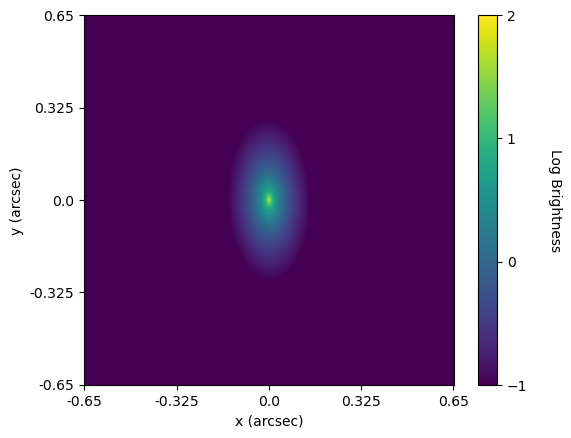

In [31]:
model_cent = Sersic2D(amplitude=1, r_eff = Re_arcsec, n = n_sersic, x_0=0, y_0=0, ellip=ellip, theta=np.radians(PA_deg))

# img is a numpy array of the Sersic profile evaluated at each point in the 2D grid defined by x_arcsec and y_arcsec. 
img = model_cent(x_arcsec, y_arcsec)
log_img = np.log10(img)

fig, ax = plt.subplots()
im = ax.imshow(log_img, origin='lower', interpolation='nearest',
               vmin=-1, vmax=2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Log Brightness', rotation=270, labelpad=25)
# Set ticks in arcseconds for the x and y axes
ax.set_xticks(np.linspace(0, n_grid-1, 5))
ax.set_xticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
ax.set_yticks(np.linspace(0, n_grid-1, 5))
ax.set_yticklabels(np.round(np.linspace(-angular_extent, angular_extent, 5), 3))
cbar.set_ticks([-1, 0, 1, 2])
plt.xlabel('x (arcsec)')
plt.ylabel('y (arcsec)')
plt.show()

In [32]:
core_radius_range_full = np.arange(2.5e-6, 30e-6+0.1e-6, 0.1e-6) # range of core radius to test, from 2.5 microns to 30 microns, in 100 steps. This is a more comprehensive range than the previous test range.
core_radius_range_full

array([2.50e-06, 2.60e-06, 2.70e-06, 2.80e-06, 2.90e-06, 3.00e-06,
       3.10e-06, 3.20e-06, 3.30e-06, 3.40e-06, 3.50e-06, 3.60e-06,
       3.70e-06, 3.80e-06, 3.90e-06, 4.00e-06, 4.10e-06, 4.20e-06,
       4.30e-06, 4.40e-06, 4.50e-06, 4.60e-06, 4.70e-06, 4.80e-06,
       4.90e-06, 5.00e-06, 5.10e-06, 5.20e-06, 5.30e-06, 5.40e-06,
       5.50e-06, 5.60e-06, 5.70e-06, 5.80e-06, 5.90e-06, 6.00e-06,
       6.10e-06, 6.20e-06, 6.30e-06, 6.40e-06, 6.50e-06, 6.60e-06,
       6.70e-06, 6.80e-06, 6.90e-06, 7.00e-06, 7.10e-06, 7.20e-06,
       7.30e-06, 7.40e-06, 7.50e-06, 7.60e-06, 7.70e-06, 7.80e-06,
       7.90e-06, 8.00e-06, 8.10e-06, 8.20e-06, 8.30e-06, 8.40e-06,
       8.50e-06, 8.60e-06, 8.70e-06, 8.80e-06, 8.90e-06, 9.00e-06,
       9.10e-06, 9.20e-06, 9.30e-06, 9.40e-06, 9.50e-06, 9.60e-06,
       9.70e-06, 9.80e-06, 9.90e-06, 1.00e-05, 1.01e-05, 1.02e-05,
       1.03e-05, 1.04e-05, 1.05e-05, 1.06e-05, 1.07e-05, 1.08e-05,
       1.09e-05, 1.10e-05, 1.11e-05, 1.12e-05, 1.13e-05, 1.14e

In [33]:
from pathlib import Path
import joblib
import numpy as np

checkpoint_dir = Path("/Users/tliu/oh_suppression/result/latest_galaxy_snr_checkpoint.txt").read_text().strip()
checkpoint_dir = Path(checkpoint_dir)

print("Using checkpoint folder:")
print(checkpoint_dir)

# Load the light checkpoint results for plotting.
# These should not contain large 2D E_image/I_image arrays.
results_bg_mmf_clad_LIGHT = joblib.load(checkpoint_dir / "results_bg_mmf_clad_LIGHT.joblib")
results_bg_mmf_core_LIGHT = joblib.load(checkpoint_dir / "results_bg_mmf_core_LIGHT.joblib")
results_ext_mmf_clad_LIGHT = joblib.load(checkpoint_dir / "results_ext_mmf_clad_LIGHT.joblib")
results_ext_mmf_core_LIGHT = joblib.load(checkpoint_dir / "results_ext_mmf_core_LIGHT.joblib")

print("Loaded light plotting checkpoints.")


Using checkpoint folder:
/Users/tliu/oh_suppression/result/galaxy_snr_2_int_cases_checkpoint_20260903_164343
Loaded light plotting checkpoints.


## Plotting cells

These cells were copied from the large notebook. The huge printed object output from the original `results_bg_mmf_clad_LIGHT` inspection cell was intentionally not copied.


In [34]:
eta_bg_cladding = np.array([res["eta_background"] for res in results_bg_mmf_clad_LIGHT])
eta_bg_core = np.array([res["eta_background"] for res in results_bg_mmf_core_LIGHT])

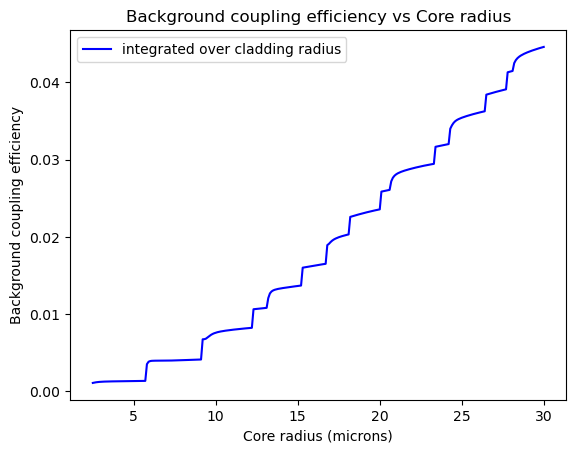

In [35]:
plt.plot(core_radius_range_full*1e6, eta_bg_cladding, color='b', label='integrated over cladding radius')
plt.xlabel('Core radius (microns)')
plt.ylabel('Background coupling efficiency')
plt.title('Background coupling efficiency vs Core radius')
plt.legend()

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# If needed:
# from oh_suppression.coupling_vs_radius_sweeps import eta_background_from_psf_weights


# -----------------------------
# Conversion functions
# -----------------------------
def radius_um_to_V(radius_um):
    radius_m = radius_um * 1e-6
    return 2 * np.pi * radius_m * NA / lam0

def V_to_radius_um(V):
    radius_m = V * lam0 / (2 * np.pi * NA)
    return radius_m * 1e6


# -----------------------------
# Mode label
# -----------------------------
def mode_label(mode):
    """
    Make labels like LP01, LP11 cos, LP11 sin, etc.
    """
    l = mode["l"]
    m = mode["m"]
    angular = mode.get("angular", "cos")

    if l == 0:
        return f"LP{l}{m}"
    else:
        return f"LP{l}{m} {angular}"


# -----------------------------
# Extract background efficiency by mode
# -----------------------------
def extract_background_efficiency_by_mode(results, core_radius_array):
    """
    For each core radius, calculate the background coupling efficiency
    for each LP mode separately.

    Missing modes are stored as NaN because not all modes exist
    at all core radii.
    """

    n_radius = len(core_radius_array)
    mode_eta_dict = {}

    for i, row in enumerate(results):
        decentre_array = row["decentre_array"]
        mode_results_decentre = row["mode_results_decentre"]

        first_decentre_modes = mode_results_decentre[0]

        for mode_index, mode in enumerate(first_decentre_modes):
            label = mode_label(mode)

            if label not in mode_eta_dict:
                mode_eta_dict[label] = np.full(n_radius, np.nan)

            eta_mode_vs_decentre = np.array([
                mode_results_at_d[mode_index]["eta"]
                for mode_results_at_d in mode_results_decentre
            ])

            eta_bg_mode = eta_background_from_psf_weights(
                decentre_array,
                eta_mode_vs_decentre
            )

            mode_eta_dict[label][i] = eta_bg_mode

    return mode_eta_dict

In [37]:
mode_eta_bg_cladding = extract_background_efficiency_by_mode(
    results_bg_mmf_clad_LIGHT,
    core_radius_range_full
)

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Conversion functions
# -----------------------------
def radius_um_to_V(radius_um):
    radius_m = radius_um * 1e-6
    return 2 * np.pi * radius_m * NA / lam0

def V_to_radius_um(V):
    radius_m = V * lam0 / (2 * np.pi * NA)
    return radius_m * 1e6


# -----------------------------
# Extract only LP01, LP02, LP03, LP04
# -----------------------------
def extract_l0_background_efficiency_by_mode(results, core_radius_array):
    """
    Extract background coupling efficiency for LP01, LP02, LP03, LP04 only.
    These are the l=0 azimuthally symmetric LP modes.
    """

    wanted_modes = {
        (0, 1): "LP01",
        (0, 2): "LP02",
        (0, 3): "LP03",
        (0, 4): "LP04",
    }

    n_radius = len(core_radius_array)

    mode_eta_dict = {
        "LP01": np.full(n_radius, np.nan),
        "LP02": np.full(n_radius, np.nan),
        "LP03": np.full(n_radius, np.nan),
        "LP04": np.full(n_radius, np.nan),
    }

    for i, row in enumerate(results):
        decentre_array = row["decentre_array"]
        mode_results_decentre = row["mode_results_decentre"]

        first_decentre_modes = mode_results_decentre[0]

        for mode_index, mode in enumerate(first_decentre_modes):
            l = mode["l"]
            m = mode["m"]

            if (l, m) not in wanted_modes:
                continue

            label = wanted_modes[(l, m)]

            eta_mode_vs_decentre = np.array([
                mode_results_at_d[mode_index]["eta"]
                for mode_results_at_d in mode_results_decentre
            ])

            eta_bg_mode = eta_background_from_psf_weights(
                decentre_array,
                eta_mode_vs_decentre
            )

            mode_eta_dict[label][i] = eta_bg_mode

    return mode_eta_dict

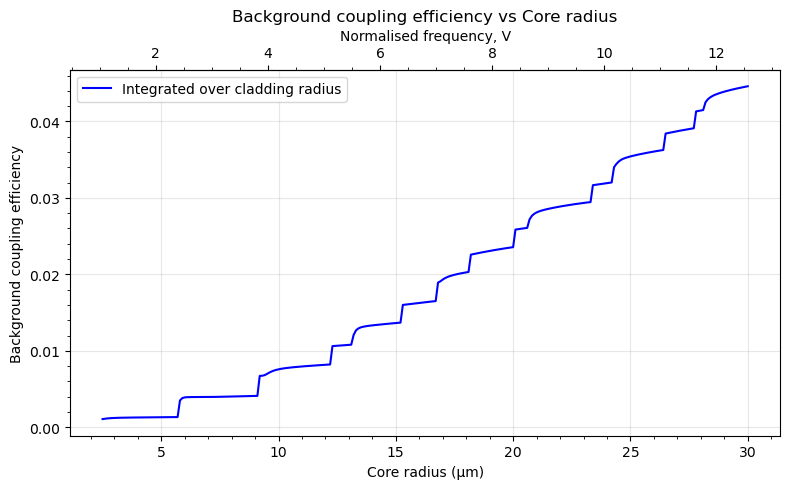

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Conversion between core radius in microns and normalised frequency V
def radius_um_to_V(radius_um):
    radius_m = radius_um * 1e-6
    return 2 * np.pi * radius_m * NA / lam0

def V_to_radius_um(V):
    radius_m = V * lam0 / (2 * np.pi * NA)
    return radius_m * 1e6


fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(
    core_radius_range_full * 1e6,
    eta_bg_cladding,
    color="b",
    label="Integrated over cladding radius"
)

ax1.set_xlabel("Core radius (µm)")
ax1.set_ylabel("Background coupling efficiency")
ax1.set_title("Background coupling efficiency vs Core radius")

ax1.minorticks_on()
ax1.grid(True, alpha=0.3)

# Add top x-axis for normalised frequency V
ax_top = ax1.secondary_xaxis(
    "top",
    functions=(radius_um_to_V, V_to_radius_um)
)

ax_top.set_xlabel("Normalised frequency, V")
ax_top.minorticks_on()

ax1.legend()

plt.tight_layout()
plt.show()

In [40]:
mode_eta_bg_cladding = extract_l0_background_efficiency_by_mode(
    results_bg_mmf_clad_LIGHT,
    core_radius_range_full
)

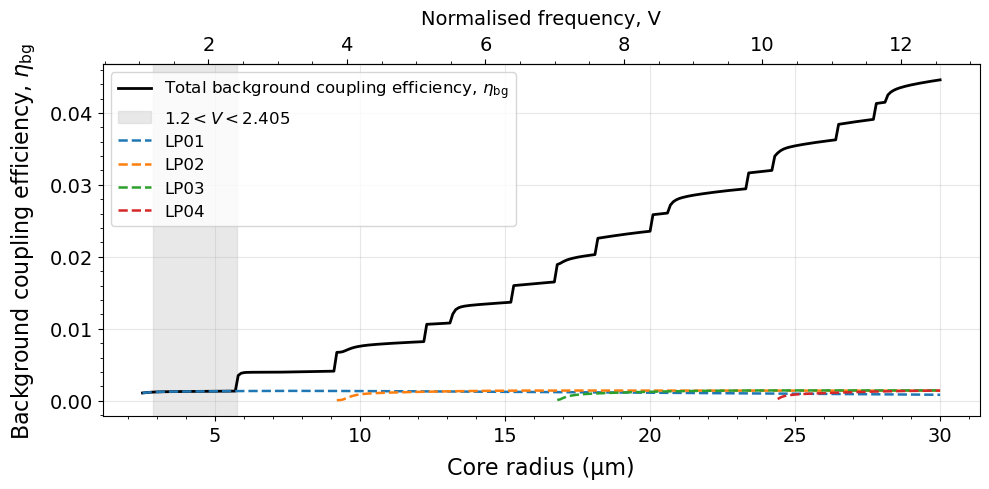

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Total background coupling efficiency
ax1.plot(
    core_radius_range_full * 1e6,
    eta_bg_cladding,
    color="black",
    linewidth=2,
    label=r"Total background coupling efficiency, $\eta_{\mathrm{bg}}$"
)

# Shade single-mode region
V_1_2 = 1.2
V_2_405 = 2.405

ax1.axvspan(
    V_to_radius_um(V_1_2),
    V_to_radius_um(V_2_405),
    color="lightgrey",
    alpha=0.5,
    label=r"$1.2 < V < 2.405$"
)

# Plot LP01, LP02, LP03, LP04 only
line_LP01, = ax1.plot(
    core_radius_range_full * 1e6,
    mode_eta_bg_cladding["LP01"],
    linestyle="dashed",
    linewidth=1.8,
    label="LP01"
)

line_LP02, = ax1.plot(
    core_radius_range_full * 1e6,
    mode_eta_bg_cladding["LP02"],
    linestyle="dashed",
    linewidth=1.8,
    label="LP02"
)

line_LP03, = ax1.plot(
    core_radius_range_full * 1e6,
    mode_eta_bg_cladding["LP03"],
    linestyle="dashed",
    linewidth=1.8,
    label="LP03"
)

line_LP04, = ax1.plot(
    core_radius_range_full * 1e6,
    mode_eta_bg_cladding["LP04"],
    linestyle="dashed",
    linewidth=1.8,
    label="LP04"
)

# Axis labels
ax1.set_xlabel("Core radius (µm)", fontsize=16, labelpad=8)
ax1.set_ylabel(r"Background coupling efficiency, $\eta_{\mathrm{bg}}$", fontsize=16, labelpad=8)

ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.minorticks_on()
ax1.grid(True, alpha=0.3)

# Top x-axis: normalised frequency V
ax_top = ax1.secondary_xaxis(
    "top",
    functions=(radius_um_to_V, V_to_radius_um)
)

ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
ax_top.tick_params(axis="x", labelsize=14)
ax_top.minorticks_on()

# Legend
ax1.legend(loc="best", fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

In [42]:
def extract_background_efficiency_all_modes(results, core_radius_array):
    """
    Extract background coupling efficiency for all LP modes.

    This includes asymmetric l != 0 modes, for example:
        LP11 cos
        LP11 sin
        LP21 cos
        LP21 sin

    Missing modes are stored as NaN because not every mode exists
    at every core radius.
    """

    n_radius = len(core_radius_array)
    mode_eta_dict = {}

    for i, row in enumerate(results):

        decentre_array = row["decentre_array"]
        mode_results_decentre = row["mode_results_decentre"]

        # Modes present at this core radius
        first_decentre_modes = mode_results_decentre[0]

        for mode_index, mode in enumerate(first_decentre_modes):

            label = mode_label(mode)

            if label not in mode_eta_dict:
                mode_eta_dict[label] = np.full(n_radius, np.nan)

            eta_mode_vs_decentre = np.array([
                mode_results_at_d[mode_index]["eta"]
                for mode_results_at_d in mode_results_decentre
            ])

            eta_bg_mode = eta_background_from_psf_weights(
                decentre_array,
                eta_mode_vs_decentre
            )

            mode_eta_dict[label][i] = eta_bg_mode

    return mode_eta_dict

In [43]:
import math

In [44]:
def plot_background_efficiency_all_modes(
    core_radius_array,
    eta_bg_total,
    results,
    title="Background coupling efficiency vs Core radius",
):
    """
    Plot total background coupling efficiency and all LP mode contributions,
    including asymmetric l != 0 modes.
    """

    mode_eta_dict = extract_background_efficiency_all_modes(
        results,
        core_radius_array
    )

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Total background coupling efficiency
    ax1.plot(
        core_radius_array * 1e6,
        eta_bg_total,
        color="black",
        linewidth=2,
        label=r"Total background coupling efficiency, $\eta_{\mathrm{bg}}$"
    )

    # Shade single-mode region
    V_1_2 = 1.2
    V_2_405 = 2.405

    ax1.axvspan(
        V_to_radius_um(V_1_2),
        V_to_radius_um(V_2_405),
        color="lightgrey",
        alpha=0.5,
        label=r"$1.2 < V < 2.405$"
    )

    # Plot all LP modes
    mode_lines = {}

    for label, eta_mode in mode_eta_dict.items():
        line, = ax1.plot(
            core_radius_array * 1e6,
            eta_mode,
            linestyle="dashed",
            linewidth=1.3,
            alpha=0.8,
            label=label
        )

        mode_lines[label] = line

    # Axis labels
    ax1.set_xlabel("Core radius (µm)", fontsize=16, labelpad=8)
    ax1.set_ylabel(
        r"Background coupling efficiency, $\eta_{\mathrm{bg}}$",
        fontsize=16,
        labelpad=8
    )

    ax1.set_title(title, fontsize=15)

    ax1.tick_params(axis="x", labelsize=14)
    ax1.tick_params(axis="y", labelsize=14)
    ax1.minorticks_on()
    ax1.grid(True, alpha=0.3)

    # Top x-axis: normalised frequency V
    ax_top = ax1.secondary_xaxis(
        "top",
        functions=(radius_um_to_V, V_to_radius_um)
    )

    ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
    ax_top.tick_params(axis="x", labelsize=14)
    ax_top.minorticks_on()

    # Legend: 4 rows, inside plot at the top, aligned with plot width
    handles, labels = ax1.get_legend_handles_labels()

    n_legend_rows = 4
    n_legend_cols = math.ceil(len(labels) / n_legend_rows)

    ax1.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        bbox_transform=ax1.transAxes,
        ncol=n_legend_cols,
        mode="expand",
        fontsize=8,
        frameon=True,
        columnspacing=0.8,
        handlelength=1.6,
        handletextpad=0.4,
        borderaxespad=0.4
    )

    plt.tight_layout()
    plt.show()

    return mode_eta_dict, mode_lines

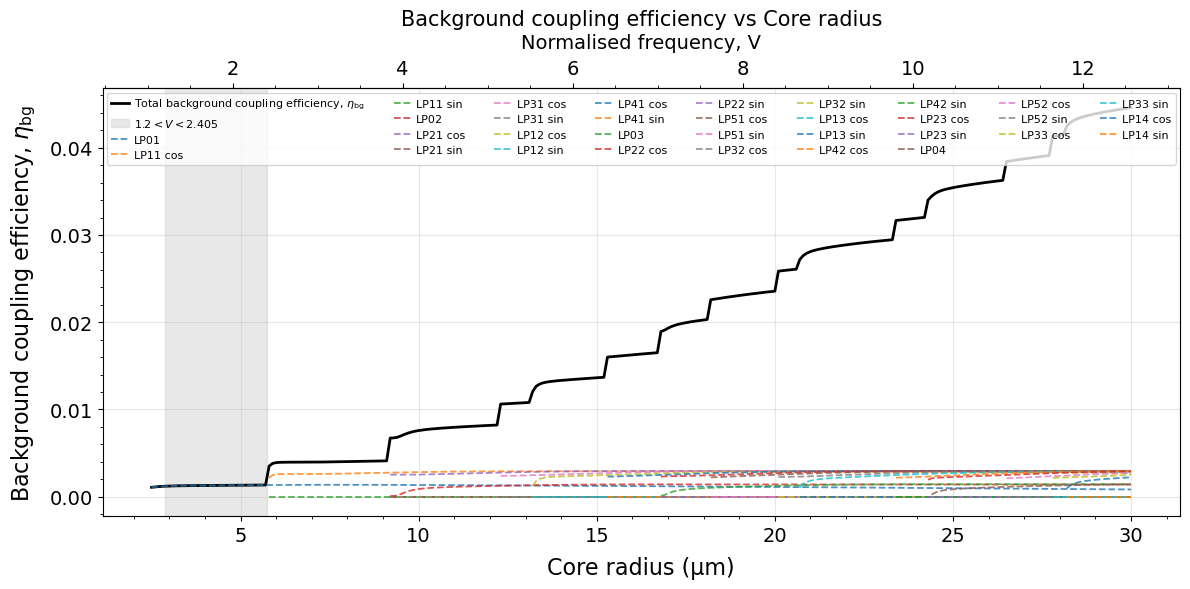

In [45]:
mode_eta_bg_cladding, mode_lines_bg_cladding = plot_background_efficiency_all_modes(
    core_radius_array=core_radius_range_full,
    eta_bg_total=eta_bg_cladding,
    results=results_bg_mmf_clad_LIGHT,
    title="Background coupling efficiency vs Core radius"
)

In [46]:
# plt.plot(core_radius_range_full*1e6, eta_bg_core, label='integrated over core radius', color='r')
# plt.xlabel('Core radius (microns)')
# plt.ylabel('Background coupling efficiency')
# plt.title('Background coupling efficiency vs Core radius')
# plt.legend()

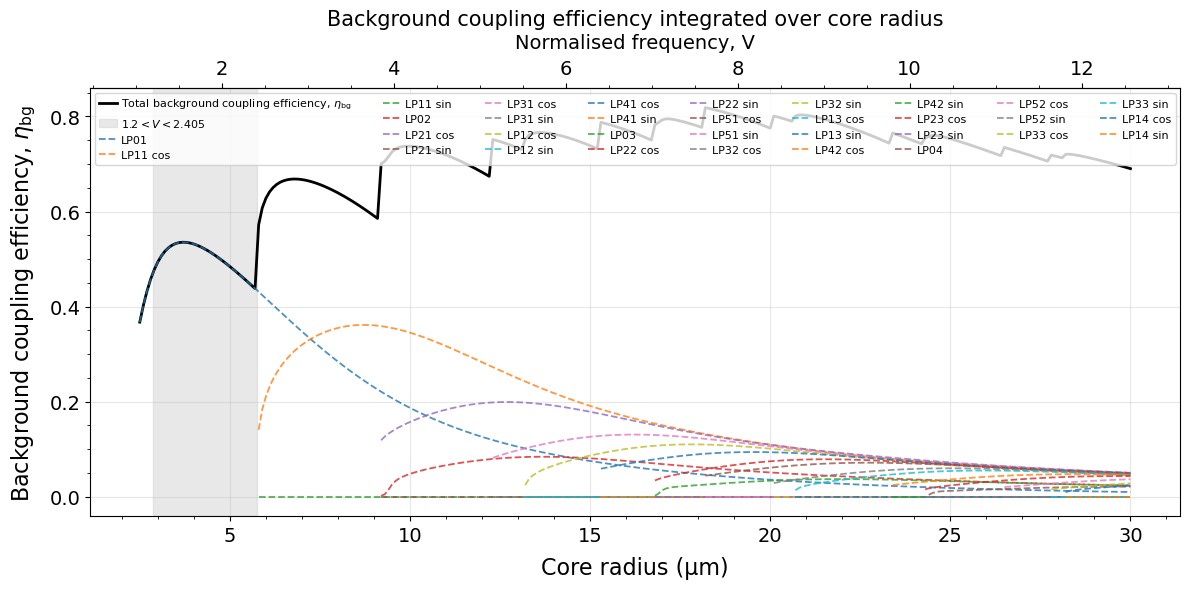

In [47]:
mode_eta_bg_core, mode_lines_bg_core = plot_background_efficiency_all_modes(
    core_radius_array=core_radius_range_full,
    eta_bg_total=eta_bg_core,
    results=results_bg_mmf_core_LIGHT,
    title="Background coupling efficiency integrated over core radius"
)

In [48]:
eta_galaxy_clad_dr = [res["eta_extended_source"] for res in results_ext_mmf_clad_LIGHT]
eta_galaxy_core_dr = [res["eta_extended_source"] for res in results_ext_mmf_core_LIGHT]

In [49]:
# plt.plot(core_radius_range_full*1e6, eta_galaxy_clad_dr, color='b', label='integrated over cladding radius')
# plt.xlabel('Core radius (microns)')
# plt.ylabel('Extended source coupling efficiency')
# plt.title('Compact galaxy (Re=0.101") coupling efficiency vs Core radius')
# plt.legend()

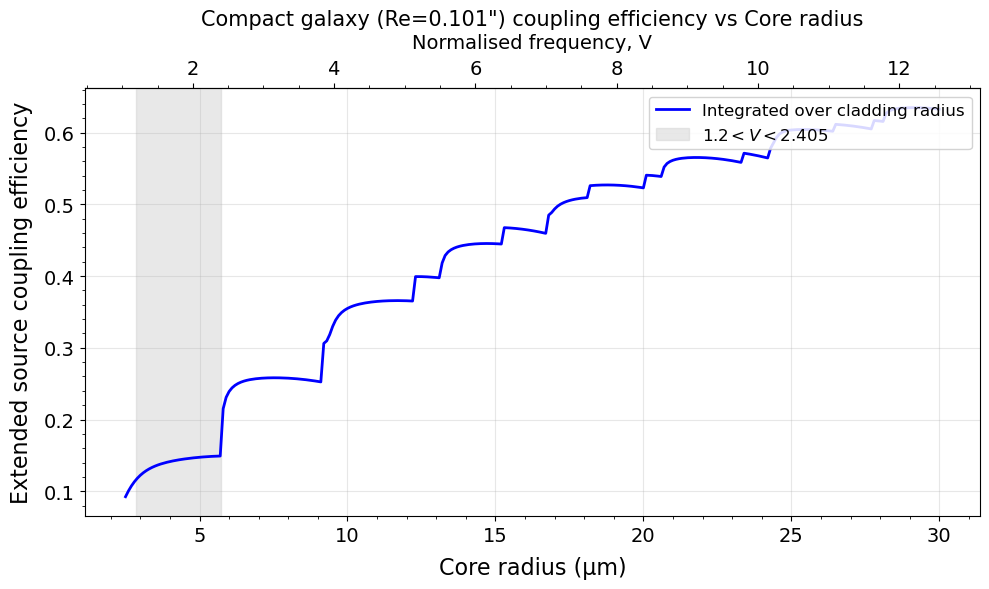

In [50]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    core_radius_range_full * 1e6,
    eta_galaxy_clad_dr,
    color="b",
    linewidth=2,
    label="Integrated over cladding radius"
)

ax1.set_xlabel("Core radius (µm)", fontsize=16, labelpad=8)
ax1.set_ylabel("Extended source coupling efficiency", fontsize=16, labelpad=8)
ax1.set_title('Compact galaxy (Re=0.101") coupling efficiency vs Core radius', fontsize=15)

ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.minorticks_on()
ax1.grid(True, alpha=0.3)

# Top x-axis: normalised frequency V
ax_top = ax1.secondary_xaxis(
    "top",
    functions=(radius_um_to_V, V_to_radius_um)
)

ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
ax_top.tick_params(axis="x", labelsize=14)
ax_top.minorticks_on()

# Shade single-mode region
V_1_2 = 1.2
V_2_405 = 2.405

ax1.axvspan(
    V_to_radius_um(V_1_2),
    V_to_radius_um(V_2_405),
    color="lightgrey",
    alpha=0.5,
    label=r"$1.2 < V < 2.405$"
)

ax1.legend(
    loc="upper right",
    fontsize=12,
    frameon=True,
    framealpha=0.85
)

plt.tight_layout()
plt.show()

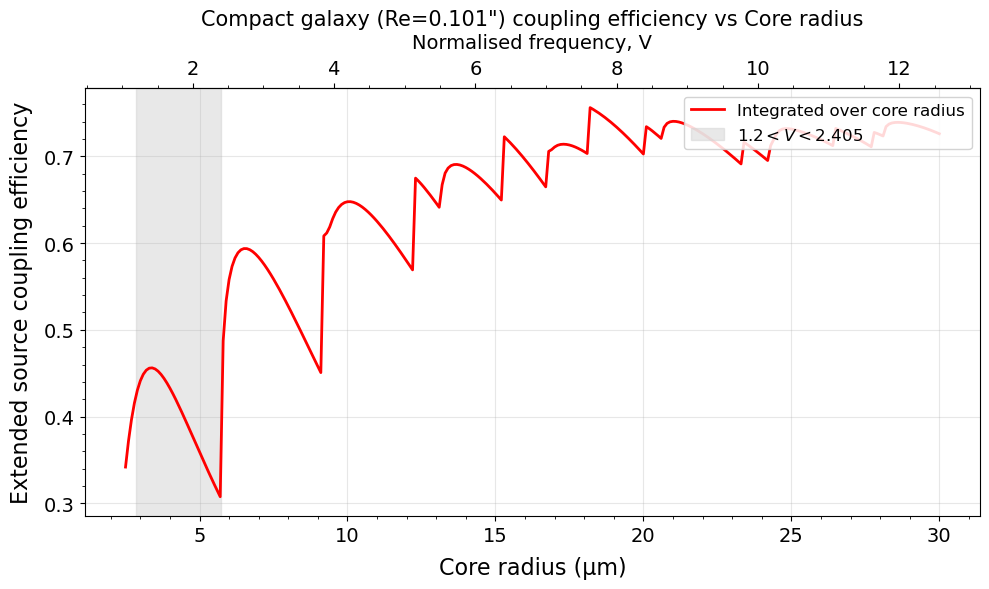

In [51]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    core_radius_range_full * 1e6,
    eta_galaxy_core_dr,
    color="r",
    linewidth=2,
    label="Integrated over core radius"
)

ax1.set_xlabel("Core radius (µm)", fontsize=16, labelpad=8)
ax1.set_ylabel("Extended source coupling efficiency", fontsize=16, labelpad=8)
ax1.set_title('Compact galaxy (Re=0.101") coupling efficiency vs Core radius', fontsize=15)

ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.minorticks_on()
ax1.grid(True, alpha=0.3)

ax_top = ax1.secondary_xaxis(
    "top",
    functions=(radius_um_to_V, V_to_radius_um)
)

ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
ax_top.tick_params(axis="x", labelsize=14)
ax_top.minorticks_on()

V_1_2 = 1.2
V_2_405 = 2.405

ax1.axvspan(
    V_to_radius_um(V_1_2),
    V_to_radius_um(V_2_405),
    color="lightgrey",
    alpha=0.5,
    label=r"$1.2 < V < 2.405$"
)

ax1.legend(
    loc="upper right",
    fontsize=12,
    frameon=True,
    framealpha=0.85
)

plt.tight_layout()
plt.show()

In [52]:
def extract_l0_extended_source_efficiency_by_mode(
    results,
    core_radius_array,
    I_source,
    x,
    y,
    x_1d,
    y_1d,
):
    """
    Extract extended-source coupling efficiency for LP01, LP02, LP03, LP04 only.

    This uses the galaxy brightness profile as the weighting function.
    """

    wanted_modes = {
        (0, 1): "LP01",
        (0, 2): "LP02",
        (0, 3): "LP03",
        (0, 4): "LP04",
    }

    n_radius = len(core_radius_array)

    mode_eta_dict = {
        "LP01": np.full(n_radius, np.nan),
        "LP02": np.full(n_radius, np.nan),
        "LP03": np.full(n_radius, np.nan),
        "LP04": np.full(n_radius, np.nan),
    }

    for i, row in enumerate(results):
        decentre_array = row["decentre_array"]
        mode_results_decentre = row["mode_results_decentre"]

        first_decentre_modes = mode_results_decentre[0]

        for mode_index, mode in enumerate(first_decentre_modes):
            l = mode["l"]
            m = mode["m"]

            if (l, m) not in wanted_modes:
                continue

            label = wanted_modes[(l, m)]

            eta_mode_vs_decentre = np.array([
                mode_results_at_d[mode_index]["eta"]
                for mode_results_at_d in mode_results_decentre
            ])

            eta_map_2d = radial_efficiency_to_2d(
                decentre_array,
                eta_mode_vs_decentre,
                x,
                y
            )

            eta_ext_mode = eta_extended_source_2d(
                eta_map_2d,
                I_source,
                x_1d,
                y_1d
            )

            mode_eta_dict[label][i] = eta_ext_mode

    return mode_eta_dict

In [53]:
def plot_galaxy_efficiency_l0_modes(
    core_radius_array,
    eta_galaxy_total,
    results,
    I_source,
    x,
    y,
    x_1d,
    y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency vs Core radius',
    total_label="Integrated over cladding radius",
    total_color="b",
):
    """
    Plot compact-galaxy coupling efficiency with LP01, LP02, LP03, LP04
    shown as dashed lines.
    """

    mode_eta_dict = extract_l0_extended_source_efficiency_by_mode(
        results=results,
        core_radius_array=core_radius_array,
        I_source=I_source,
        x=x,
        y=y,
        x_1d=x_1d,
        y_1d=y_1d,
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Total extended-source coupling efficiency
    ax1.plot(
        core_radius_array * 1e6,
        eta_galaxy_total,
        color=total_color,
        linewidth=2,
        label=total_label
    )

    # Shade single-mode region
    V_1_2 = 1.2
    V_2_405 = 2.405

    ax1.axvspan(
        V_to_radius_um(V_1_2),
        V_to_radius_um(V_2_405),
        color="lightgrey",
        alpha=0.5,
        label=r"$1.2 < V < 2.405$"
    )

    # LP01, LP02, LP03, LP04 dashed lines
    line_LP01, = ax1.plot(
        core_radius_array * 1e6,
        mode_eta_dict["LP01"],
        linestyle="dashed",
        linewidth=1.8,
        label="LP01"
    )

    line_LP02, = ax1.plot(
        core_radius_array * 1e6,
        mode_eta_dict["LP02"],
        linestyle="dashed",
        linewidth=1.8,
        label="LP02"
    )

    line_LP03, = ax1.plot(
        core_radius_array * 1e6,
        mode_eta_dict["LP03"],
        linestyle="dashed",
        linewidth=1.8,
        label="LP03"
    )

    line_LP04, = ax1.plot(
        core_radius_array * 1e6,
        mode_eta_dict["LP04"],
        linestyle="dashed",
        linewidth=1.8,
        label="LP04"
    )

    # Axis labels
    ax1.set_xlabel("Core radius (µm)", fontsize=14, labelpad=8)
    ax1.set_ylabel("Extended source coupling efficiency", fontsize=14, labelpad=8)
    ax1.set_title(title, fontsize=18, pad=15)

    ax1.tick_params(axis="x", labelsize=12)
    ax1.tick_params(axis="y", labelsize=12)
    ax1.minorticks_on()
    ax1.grid(True, alpha=0.3)

    # Top x-axis: normalised frequency V
    ax_top = ax1.secondary_xaxis(
        "top",
        functions=(radius_um_to_V, V_to_radius_um)
    )

    ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
    ax_top.tick_params(axis="x", labelsize=14)
    ax_top.minorticks_on()

    # Legend inside plot at the top
    ax1.legend(
        loc="upper center",
        fontsize=9,
        frameon=True,
        framealpha=0.85,
        ncol=3
    )

    plt.tight_layout()
    plt.show()

    mode_lines = {
        "LP01": line_LP01,
        "LP02": line_LP02,
        "LP03": line_LP03,
        "LP04": line_LP04,
    }

    return mode_eta_dict, mode_lines

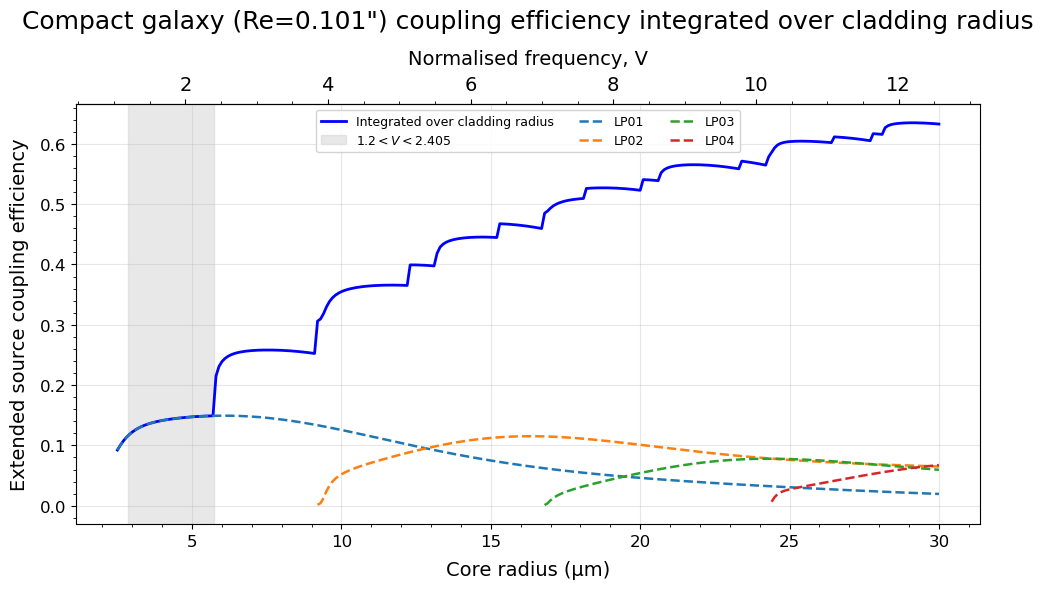

In [54]:
mode_eta_galaxy_clad, mode_lines_galaxy_clad = plot_galaxy_efficiency_l0_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_clad_dr,
    results=results_ext_mmf_clad_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency integrated over cladding radius',
    total_label="Integrated over cladding radius",
    total_color="b"
)

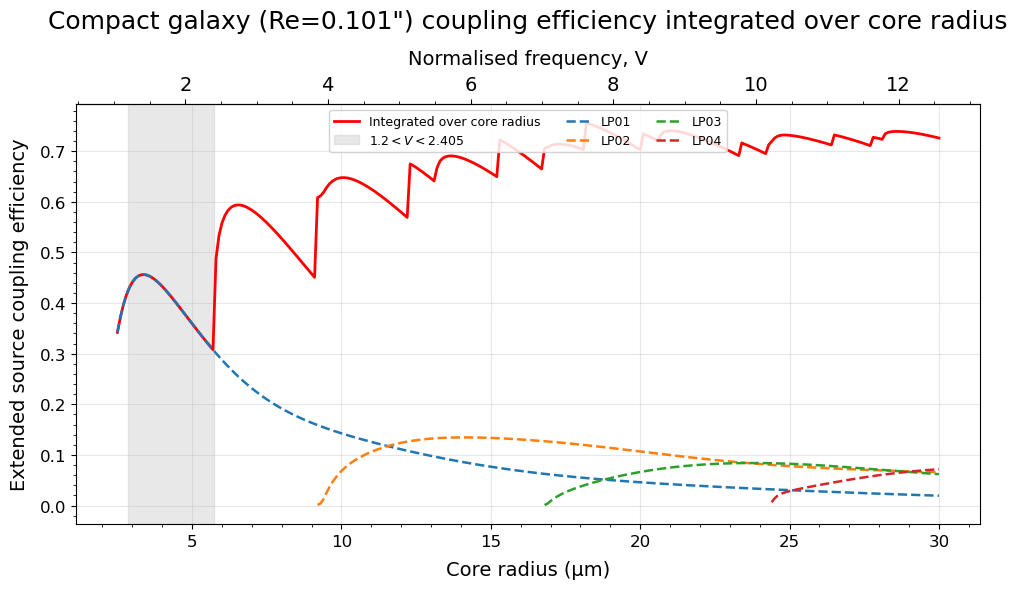

In [55]:
mode_eta_galaxy_core, mode_lines_galaxy_core = plot_galaxy_efficiency_l0_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_core_dr,
    results=results_ext_mmf_core_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency integrated over core radius',
    total_label="Integrated over core radius",
    total_color="r"
)

In [56]:
def extract_extended_source_efficiency_all_modes(
    results,
    core_radius_array,
    I_source,
    x,
    y,
    x_1d,
    y_1d,
):
    """
    Extract extended-source coupling efficiency for all LP modes.

    This includes asymmetric l != 0 modes, for example:
        LP11 cos
        LP11 sin
        LP21 cos
        LP21 sin

    Missing modes are stored as NaN because not every mode exists
    at every core radius.
    """

    n_radius = len(core_radius_array)
    mode_eta_dict = {}

    for i, row in enumerate(results):

        decentre_array = row["decentre_array"]
        mode_results_decentre = row["mode_results_decentre"]

        # Modes present at this core radius
        first_decentre_modes = mode_results_decentre[0]

        for mode_index, mode in enumerate(first_decentre_modes):

            label = mode_label(mode)

            if label not in mode_eta_dict:
                mode_eta_dict[label] = np.full(n_radius, np.nan)

            eta_mode_vs_decentre = np.array([
                mode_results_at_d[mode_index]["eta"]
                for mode_results_at_d in mode_results_decentre
            ])

            eta_map_2d = radial_efficiency_to_2d(
                decentre_array,
                eta_mode_vs_decentre,
                x,
                y
            )

            eta_ext_mode = eta_extended_source_2d(
                eta_map_2d,
                I_source,
                x_1d,
                y_1d
            )

            mode_eta_dict[label][i] = eta_ext_mode

    return mode_eta_dict

In [57]:
def plot_galaxy_efficiency_all_modes(
    core_radius_array,
    eta_galaxy_total,
    results,
    I_source,
    x,
    y,
    x_1d,
    y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency vs Core radius',
    total_label="Integrated over cladding radius",
    total_color="b",
):
    """
    Plot compact-galaxy coupling efficiency and all LP mode contributions,
    including asymmetric l != 0 modes.
    """

    mode_eta_dict = extract_extended_source_efficiency_all_modes(
        results=results,
        core_radius_array=core_radius_array,
        I_source=I_source,
        x=x,
        y=y,
        x_1d=x_1d,
        y_1d=y_1d,
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Total extended-source coupling efficiency
    ax1.plot(
        core_radius_array * 1e6,
        eta_galaxy_total,
        color=total_color,
        linewidth=2,
        label=total_label
    )

    # Shade single-mode region
    V_1_2 = 1.2
    V_2_405 = 2.405

    ax1.axvspan(
        V_to_radius_um(V_1_2),
        V_to_radius_um(V_2_405),
        color="lightgrey",
        alpha=0.5,
        label=r"$1.2 < V < 2.405$"
    )

    # Plot all LP modes
    mode_lines = {}

    for label, eta_mode in mode_eta_dict.items():
        line, = ax1.plot(
            core_radius_array * 1e6,
            eta_mode,
            linestyle="dashed",
            linewidth=1.3,
            alpha=0.8,
            label=label
        )

        mode_lines[label] = line

    # Axis labels
    ax1.set_xlabel("Core radius (µm)", fontsize=16, labelpad=8)
    ax1.set_ylabel("Extended source coupling efficiency", fontsize=16, labelpad=8)
    ax1.set_title(title, fontsize=15)

    ax1.tick_params(axis="x", labelsize=14)
    ax1.tick_params(axis="y", labelsize=14)
    ax1.minorticks_on()
    ax1.grid(True, alpha=0.3)

    # Top x-axis: normalised frequency V
    ax_top = ax1.secondary_xaxis(
        "top",
        functions=(radius_um_to_V, V_to_radius_um)
    )

    ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
    ax_top.tick_params(axis="x", labelsize=14)
    ax_top.minorticks_on()

    # Legend: 4 rows, inside plot at the top, aligned with plot width
    handles, labels = ax1.get_legend_handles_labels()

    n_legend_rows = 4
    n_legend_cols = math.ceil(len(labels) / n_legend_rows)

    ax1.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        bbox_transform=ax1.transAxes,
        ncol=n_legend_cols,
        mode="expand",
        fontsize=8,
        frameon=True,
        framealpha=0.85,
        columnspacing=0.8,
        handlelength=1.6,
        handletextpad=0.4,
        borderaxespad=0.4
    )

    plt.tight_layout()
    plt.show()

    return mode_eta_dict, mode_lines

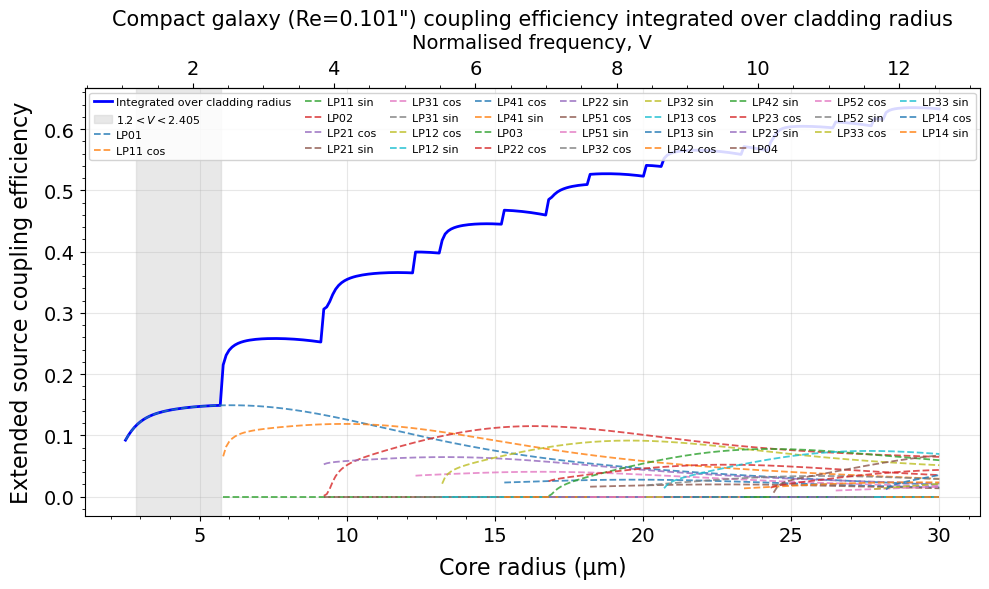

In [58]:
mode_eta_galaxy_clad_all, mode_lines_galaxy_clad_all = plot_galaxy_efficiency_all_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_clad_dr,
    results=results_ext_mmf_clad_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency integrated over cladding radius',
    total_label="Integrated over cladding radius",
    total_color="b"
)

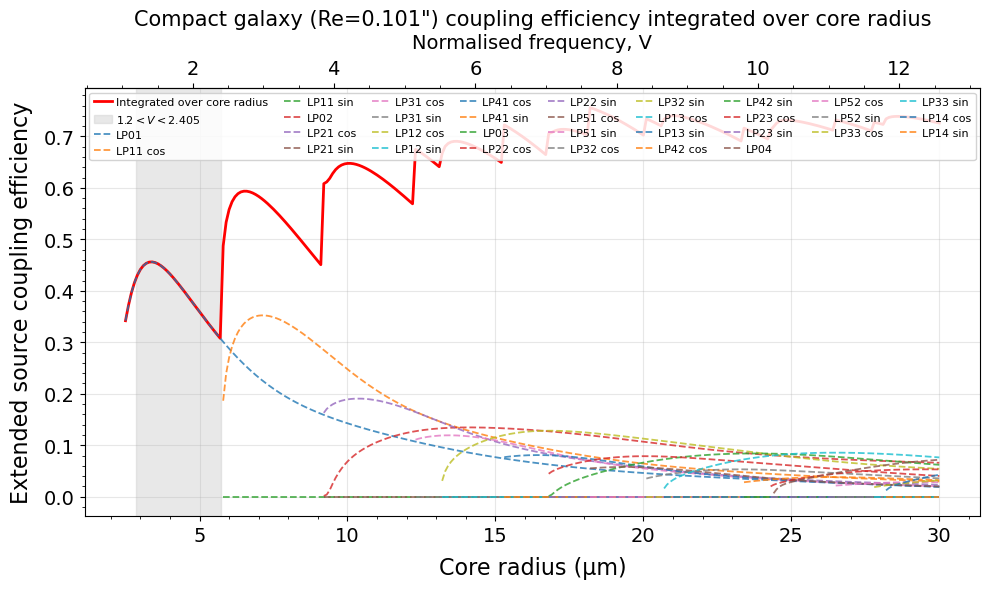

In [59]:
mode_eta_galaxy_core_all, mode_lines_galaxy_core_all = plot_galaxy_efficiency_all_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_core_dr,
    results=results_ext_mmf_core_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy (Re=0.101") coupling efficiency integrated over core radius',
    total_label="Integrated over core radius",
    total_color="r"
)

In [60]:
def plot_galaxy_efficiency_asymmetric_modes(
    core_radius_array,
    eta_galaxy_total,
    results,
    I_source,
    x,
    y,
    x_1d,
    y_1d,
    title='Compact galaxy asymmetric LP mode coupling efficiency vs Core radius',
    total_label="Total extended-source coupling efficiency",
    total_color="black",
):
    """
    Plot compact-galaxy coupling efficiency for asymmetric LP modes only,
    with the total extended-source coupling efficiency included.

    This excludes the symmetric l = 0 modes:
        LP01, LP02, LP03, LP04, ...

    For each asymmetric mode:
        cos component = dashed line
        sin component = dotted line

    The cos and sin components of the same LP mode use the same colour.
    """

    mode_eta_dict = extract_extended_source_efficiency_all_modes(
        results=results,
        core_radius_array=core_radius_array,
        I_source=I_source,
        x=x,
        y=y,
        x_1d=x_1d,
        y_1d=y_1d,
    )

    # Keep only asymmetric modes, i.e. labels like "LP11 cos", "LP11 sin"
    asymmetric_mode_eta_dict = {
        label: eta_mode
        for label, eta_mode in mode_eta_dict.items()
        if (" cos" in label) or (" sin" in label)
    }

    # Get the base mode names: LP11, LP21, LP31, ...
    base_modes = sorted(
        set(label.split()[0] for label in asymmetric_mode_eta_dict.keys())
    )

    # Assign one colour to each base LP mode using turbo colormap
    cmap = plt.cm.turbo
    colours = cmap(np.linspace(0, 1, len(base_modes)))

    colour_dict = {
        base_mode: colours[i]
        for i, base_mode in enumerate(base_modes)
    }

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Total extended-source coupling efficiency
    ax1.plot(
        core_radius_array * 1e6,
        eta_galaxy_total,
        color=total_color,
        linewidth=2.2,
        label=total_label
    )

    # Shade single-mode region
    V_1_2 = 1.2
    V_2_405 = 2.405

    ax1.axvspan(
        V_to_radius_um(V_1_2),
        V_to_radius_um(V_2_405),
        color="lightgrey",
        alpha=0.5,
        label=r"$1.2 < V < 2.405$"
    )

    mode_lines = {}

    for base_mode in base_modes:

        cos_label = f"{base_mode} cos"
        sin_label = f"{base_mode} sin"

        colour = colour_dict[base_mode]

        if cos_label in asymmetric_mode_eta_dict:
            line_cos, = ax1.plot(
                core_radius_array * 1e6,
                asymmetric_mode_eta_dict[cos_label],
                linestyle="dashed",
                linewidth=1.5,
                alpha=0.9,
                color=colour,
                label=cos_label
            )

            mode_lines[cos_label] = line_cos

        if sin_label in asymmetric_mode_eta_dict:
            line_sin, = ax1.plot(
                core_radius_array * 1e6,
                asymmetric_mode_eta_dict[sin_label],
                linestyle="dotted",
                linewidth=1.8,
                alpha=0.9,
                color=colour,
                label=sin_label
            )

            mode_lines[sin_label] = line_sin

    # Axis labels
    ax1.set_xlabel("Core radius (µm)", fontsize=14, labelpad=8)
    ax1.set_ylabel("Extended source coupling efficiency", fontsize=14, labelpad=8)
    ax1.set_title(title, fontsize=18, pad=15)

    ax1.tick_params(axis="x", labelsize=12)
    ax1.tick_params(axis="y", labelsize=12)
    ax1.minorticks_on()
    ax1.grid(True, alpha=0.3)

    # Top x-axis: normalised frequency V
    ax_top = ax1.secondary_xaxis(
        "top",
        functions=(radius_um_to_V, V_to_radius_um)
    )

    ax_top.set_xlabel("Normalised frequency, V", fontsize=14, labelpad=8)
    ax_top.tick_params(axis="x", labelsize=14)
    ax_top.minorticks_on()

    # Legend: 4 rows, inside plot at the top, aligned with plot width
    handles, labels = ax1.get_legend_handles_labels()

    n_legend_rows = 4
    n_legend_cols = math.ceil(len(labels) / n_legend_rows)

    ax1.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        bbox_transform=ax1.transAxes,
        ncol=n_legend_cols,
        mode="expand",
        fontsize=8,
        frameon=True,
        framealpha=0.85,
        columnspacing=0.8,
        handlelength=1.6,
        handletextpad=0.4,
        borderaxespad=0.4
    )

    plt.tight_layout()
    plt.show()

    return asymmetric_mode_eta_dict, mode_lines

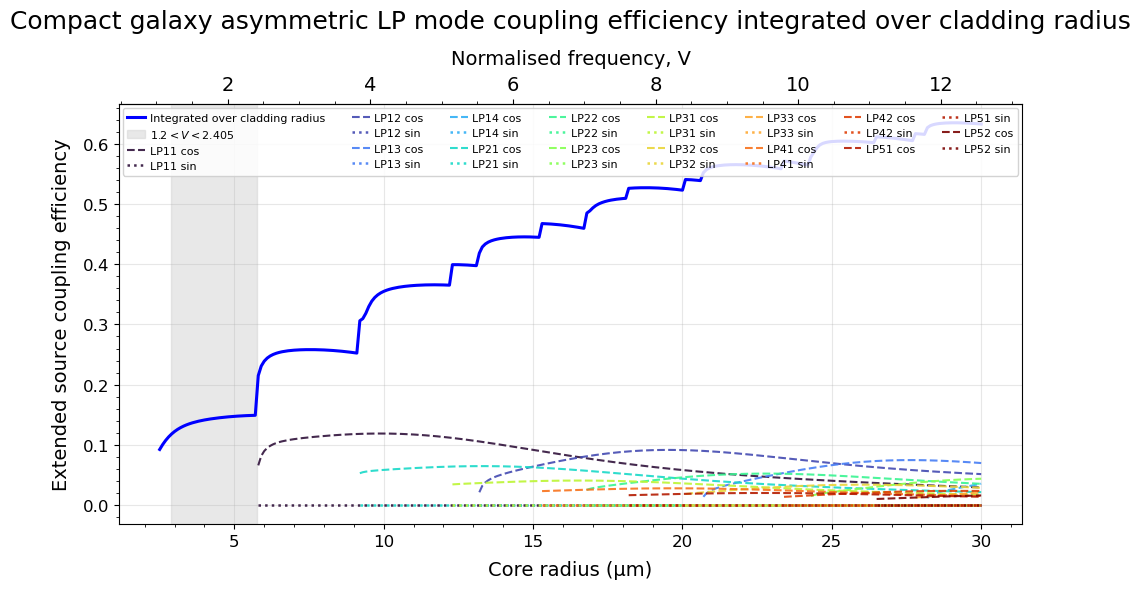

In [61]:
mode_eta_galaxy_clad_asym, mode_lines_galaxy_clad_asym = plot_galaxy_efficiency_asymmetric_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_clad_dr,
    results=results_ext_mmf_clad_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy asymmetric LP mode coupling efficiency integrated over cladding radius',
    total_label="Integrated over cladding radius",
    total_color="b"
)

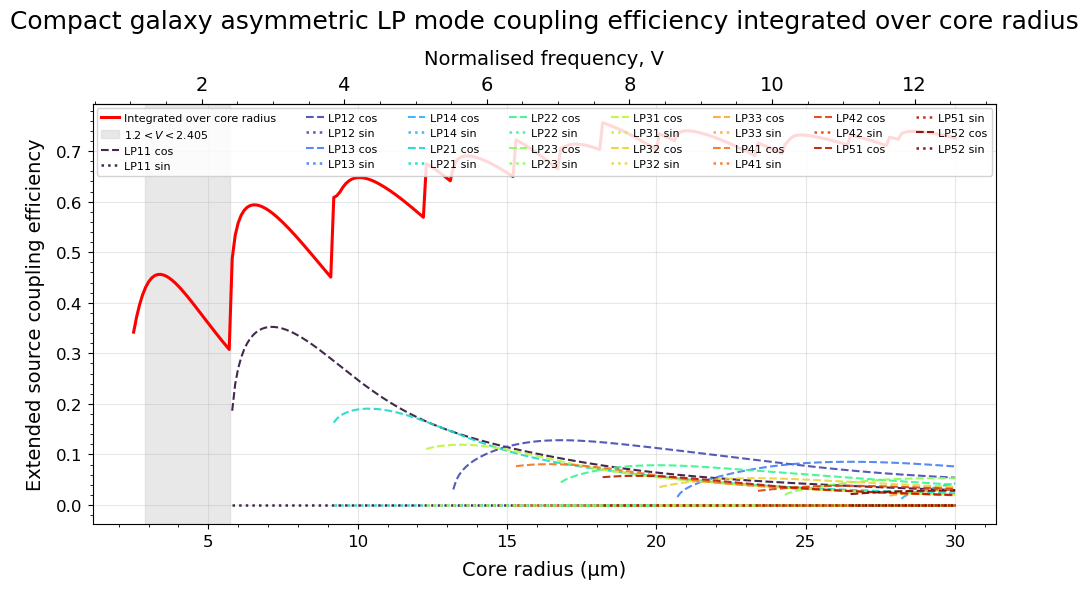

In [62]:
mode_eta_galaxy_core_asym, mode_lines_galaxy_core_asym = plot_galaxy_efficiency_asymmetric_modes(
    core_radius_array=core_radius_range_full,
    eta_galaxy_total=eta_galaxy_core_dr,
    results=results_ext_mmf_core_LIGHT,
    I_source=img,
    x=x,
    y=y,
    x_1d=x_1d,
    y_1d=y_1d,
    title='Compact galaxy asymmetric LP mode coupling efficiency integrated over core radius',
    total_label="Integrated over core radius",
    total_color="r"
)

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\ '
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_36929/3746888682.py:2: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Compare results via ratio between $\eta_{ext,cladding}$ and $\eta_{ext,core}$")
/var/folders/pk/ftg5vwzs3r1dhbzyhbqk09580000gp/T/ipykernel_36929/3746888682.py:4: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('$\\eta_{ext,cladding}\ /\ \\eta_{ext,core}$')


Text(0, 0.5, '$\\eta_{ext,cladding}\\ /\\ \\eta_{ext,core}$')

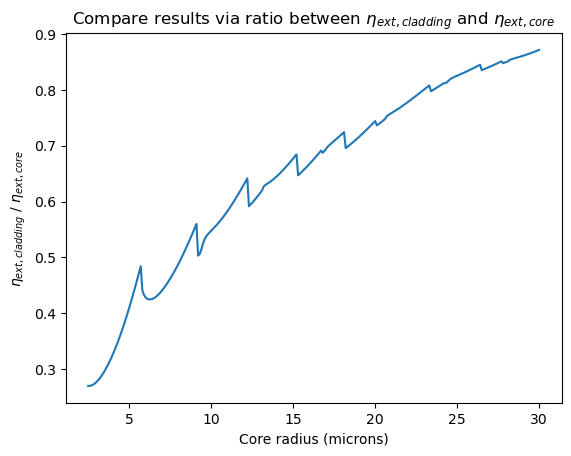

In [63]:
plt.plot(core_radius_range_full*1e6, np.divide(eta_galaxy_clad_dr, eta_galaxy_core_dr))
plt.title("Compare results via ratio between $\eta_{ext,cladding}$ and $\eta_{ext,core}$")
plt.xlabel('Core radius (microns)')
plt.ylabel('$\\eta_{ext,cladding}\ /\ \\eta_{ext,core}$')

In [64]:
# SNR plot for cladding case

I_flat = 1 **2 # flat intensity of the background noise across the fibre input plane, in normalised units

rad_to_arcsec = (180 / np.pi) * 3600 # conversion factor from radians to arcseconds

plate_scale_coude = rad_to_arcsec / (F_focus * D_M1) # in arcseconds per meter at the focal plane
plate_scale_demag = plate_scale_coude / Magnification # in arcseconds per meter at the fibre input plane

FOV_array = np.zeros_like(core_radius_range_full)
snr_array = np.zeros_like(core_radius_range_full)
signal_array = np.zeros_like(core_radius_range_full)
background_array = np.zeros_like(core_radius_range_full)

for i, a in enumerate(core_radius_range_full): 
    # # Calculate Field of View for the fibre
    # # plate scale = FOV / fibre radius, so FOV = plate scale * fibre radius (in arcseconds)
    FOV = plate_scale_demag * 2*a # in arcseconds 

    # r_FOV = np.linspace(0, FOV, 10000) * plate_scale_demag # Convert FOV from arcseconds to meters at the fibre input plane for the core region
    
    # Signal = 2*np.pi * integrate.simpson(I_image * fibre_r, x=fibre_r) # Total signal coupled into the fibre, integrating over the fibre cross-section
    Background_area = np.pi * I_flat * (FOV / 2) **2  # Total noise coupled into the fibre, integrating over the fibre cross-section

    # signal_array = np.array(eta_galaxy_clad_dr) #for now ignore the integrated brightness of galaxy

    # background_array = np.array(eta_bg_cladding) * I_flat #for now ignore the integrated brightness of background

    signal = eta_galaxy_clad_dr[i]
    background = eta_bg_cladding[i] * I_flat

    snr = signal / np.sqrt(Background_area * background) # Signal-to-noise ratio, assuming noise is dominated by the background and follows Poisson statistics

    FOV_array[i] = FOV
    snr_array[i] = snr
    signal_array[i] = signal
    background_array[i] = background



In [65]:
snr_array

array([122.54189571, 125.45306809, 127.09151676, 127.710439  ,
       127.53292681, 126.74608898, 125.50272121, 123.92514951,
       122.10937823, 120.1302615 , 118.04515487, 115.89768064,
       113.72090754, 111.53939927, 109.37136883, 107.22993841,
       105.12432803, 103.0610174 , 101.04415453,  99.07631592,
        97.15874842,  95.29169069,  93.47483684,  91.70730371,
        89.98794127,  88.31528738,  86.68767696,  85.10345599,
        83.56087745,  82.05824161,  80.59380876,  79.16585092,
        77.77275051,  68.14730098,  68.93969528,  69.37133153,
        69.41227888,  69.17203135,  68.7373961 ,  68.1684135 ,
        67.50603698,  66.77861623,  66.00616196,  65.20308665,
        64.37986399,  63.54414931,  62.70158433,  61.85640448,
        61.01186681,  60.17040176,  59.33381496,  58.50342153,
        57.68022551,  56.86502115,  56.05837245,  55.26065834,
        54.47211605,  53.69289428,  52.92312465,  52.16285699,
        51.41207399,  50.67071897,  49.93869966,  49.21

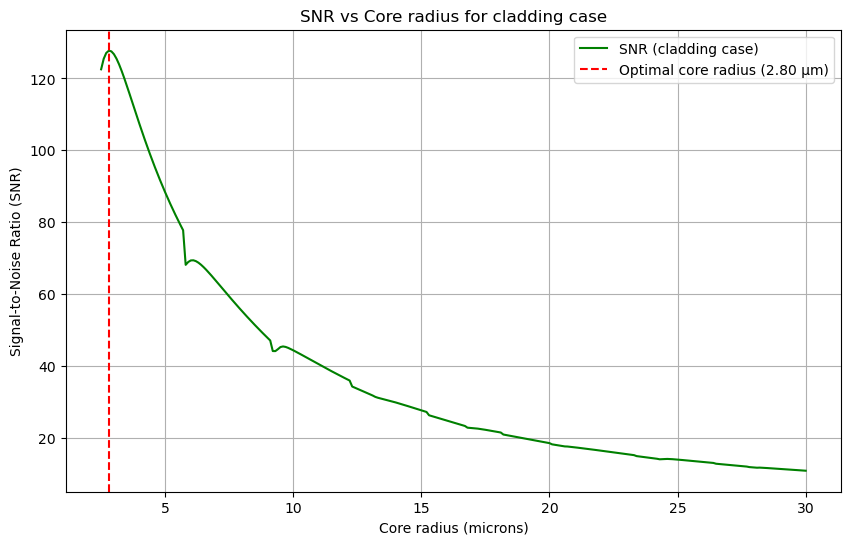

In [66]:
# Plot SNR vs Core radius

plt.figure(figsize=(10, 6))
plt.plot(core_radius_range_full*1e6, snr_array, color='g', label='SNR (cladding case)')
plt.axvline(core_radius_range_full[np.argmax(snr_array)] * 1e6, color='red', linestyle='dashed', label=f"Optimal core radius ({core_radius_range_full[np.argmax(snr_array)] * 1e6:.2f} µm)")
plt.xlabel('Core radius (microns)')
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.title('SNR vs Core radius for cladding case')
plt.grid()
plt.legend()

In [67]:
# SNR plot for core case

I_flat = 1 **2 # flat intensity of the background noise across the fibre input plane, in normalised units

rad_to_arcsec = (180 / np.pi) * 3600 # conversion factor from radians to arcseconds

plate_scale_coude = rad_to_arcsec / (F_focus * D_M1) # in arcseconds per meter at the focal plane
plate_scale_demag = plate_scale_coude / Magnification # in arcseconds per meter at the fibre input plane

FOV_array = np.zeros_like(core_radius_range_full)
snr_array_core = np.zeros_like(core_radius_range_full)
signal_array_core = np.zeros_like(core_radius_range_full)
background_array_core = np.zeros_like(core_radius_range_full)

for i, a in enumerate(core_radius_range_full): 
    # # Calculate Field of View for the fibre
    # # plate scale = FOV / fibre radius, so FOV = plate scale * fibre radius (in arcseconds)
    FOV = plate_scale_demag * 2*a # in arcseconds 

    # r_FOV = np.linspace(0, FOV, 10000) * plate_scale_demag # Convert FOV from arcseconds to meters at the fibre input plane for the core region
    
    # Signal = 2*np.pi * integrate.simpson(I_image * fibre_r, x=fibre_r) # Total signal coupled into the fibre, integrating over the fibre cross-section
    Background_area = np.pi * I_flat * (FOV / 2) **2  # Total noise coupled into the fibre, integrating over the fibre cross-section

    # signal_array = np.array(eta_galaxy_clad_dr) #for now ignore the integrated brightness of galaxy

    # background_array = np.array(eta_bg_cladding) * I_flat #for now ignore the integrated brightness of background

    signal = eta_galaxy_core_dr[i]
    background = eta_bg_core[i] * I_flat

    snr = signal / np.sqrt(Background_area * background) # Signal-to-noise ratio, assuming noise is dominated by the background and follows Poisson statistics

    FOV_array[i] = FOV
    snr_array_core[i] = snr
    signal_array_core[i] = signal
    background_array_core[i] = background


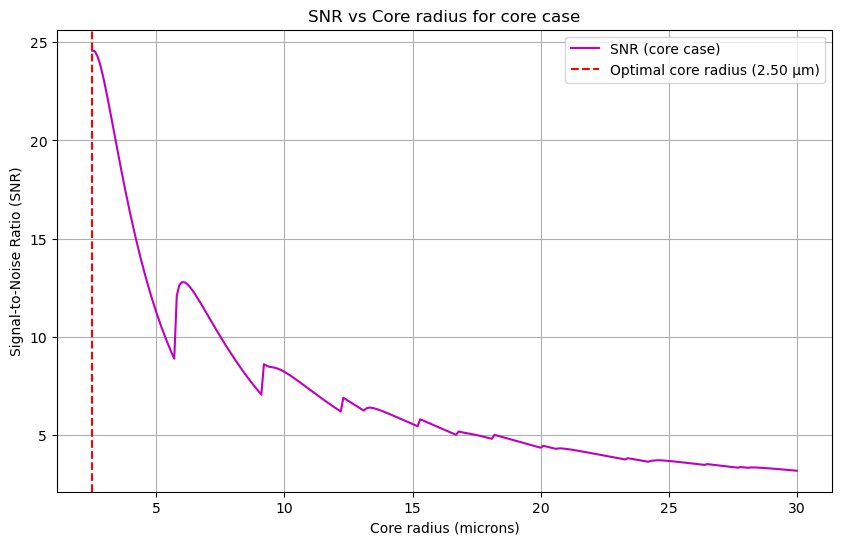

In [68]:
# Plot SNR vs Core radius for core case

plt.figure(figsize=(10, 6))
plt.plot(core_radius_range_full*1e6, snr_array_core, color='m', label='SNR (core case)')
plt.axvline(core_radius_range_full[np.argmax(snr_array_core)] * 1e6, color='red', linestyle='dashed', label=f"Optimal core radius ({core_radius_range_full[np.argmax(snr_array_core)] * 1e6:.2f} µm)")
plt.xlabel('Core radius (microns)')
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.title('SNR vs Core radius for core case')
plt.grid()
plt.legend()